# Fase 3 — Análise Exploratória e Entendimento do Problema

**Tech Challenge — Predição e Inteligência Analítica para Alfabetização no Brasil**

Este notebook percorre a etapa exploratória do projeto: entender o comportamento dos dados,
identificar padrões, avaliar distribuições, detectar correlações e formular as hipóteses que
guiam as decisões de modelagem tomadas nos notebooks seguintes.

A fonte são os microdados da Avaliação da Alfabetização (INEP, 2023–2025), as metas do
Compromisso Nacional Criança Alfabetizada e o enriquecimento territorial/socioeconômico do IBGE —
as mesmas integrações construídas na camada Gold da Fase 2, agora reproduzidas em Python.

In [1]:
import sys
sys.path.append("..")

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config
from src.preprocessing import features, loaders
from src.visualization import plots

plots.aplicar_estilo()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

## 1. O problema em uma frase

A partir da Pesquisa Alfabetiza Brasil (INEP, 2023), o Saeb passou a usar **743 pontos** como ponto
de corte da escala de Língua Portuguesa do 2º ano: acima disso, a criança é considerada
alfabetizada. O Compromisso Nacional Criança Alfabetizada estabelece que, até **2030**, 80% das
crianças estejam alfabetizadas ao fim do 2º ano.

Nossa pergunta: **dá para antecipar quem fica abaixo desse corte — e onde — antes da avaliação acontecer?**

In [2]:
alunos = {ano: loaders.carregar_alunos(ano) for ano in config.ANOS}
for ano, df in alunos.items():
    print(f"{ano}: {len(df):>9,} registros | {df['id_municipio'].nunique():>5,} municípios "
          f"| {df['id_escola'].nunique():>6,} escolas".replace(",", "."))

2023: 1.747.439 registros | 4.873 municípios | 36.776 escolas
2024: 2.120.560 registros | 5.519 municípios | 42.497 escolas
2025: 2.222.792 registros | 5.556 municípios | 43.644 escolas


## 2. Universo de análise: quem entra na base

O INEP registra `IN_ALFABETIZADO = 0` para alunos **ausentes** na aplicação — não porque foram
avaliados e ficaram abaixo do corte, mas porque não há proficiência calculada. Manter esses
registros tornaria o alvo trivialmente previsível pela ausência, e o modelo aprenderia a prever
falta escolar, não alfabetização.

**Decisão:** o universo de modelagem são os alunos presentes e com proficiência calculada.

In [3]:
resumo = []
for ano, df in alunos.items():
    presentes = df[(df["presente"] == 1) & df["proficiencia"].notna()]
    resumo.append({
        "ano": ano,
        "registros": len(df),
        "ausentes_%": (df["presente"] == 0).mean() * 100,
        "base_modelagem": len(presentes),
        "alfabetizados_%": presentes["alfabetizado"].mean() * 100,
        "proficiencia_media": presentes["proficiencia"].mean(),
    })
pd.DataFrame(resumo).round(2)

,ano,registros,ausentes_%,base_modelagem,alfabetizados_%,proficiencia_media
0,2023,1747439,13.99,1502809,58.39,747.559998
1,2024,2120560,12.63,1851852,59.78,749.039978
2,2025,2222792,11.38,1966605,66.26,753.570007


### Consistência do alvo com o ponto de corte oficial

Antes de qualquer modelagem, confirmamos que o rótulo publicado pelo INEP corresponde exatamente
à regra dos 743 pontos. Se houvesse divergência, todo o desenho do alvo estaria comprometido.

In [4]:
for ano, df in alunos.items():
    p = df[(df["presente"] == 1) & df["proficiencia"].notna()]
    coincide = ((p["proficiencia"] >= config.CORTE_ALFABETIZACAO).astype(int) == p["alfabetizado"]).mean()
    print(f"{ano}: {coincide:.6%} dos rótulos coincidem com proficiência >= {config.CORTE_ALFABETIZACAO:.0f}")

2023: 100.000000% dos rótulos coincidem com proficiência >= 743


2024: 100.000000% dos rótulos coincidem com proficiência >= 743


2025: 100.000000% dos rótulos coincidem com proficiência >= 743


## 3. Distribuição da proficiência

A distribuição é aproximadamente normal e desloca-se para a direita ano a ano. O corte de 743 cai
perto do centro da distribuição — ou seja, **uma parcela enorme de crianças está muito próxima da
linha**, o que tem uma consequência direta para a modelagem: pequenas variações de contexto viram
mudança de classe, e o teto de acurácia individual é naturalmente limitado.

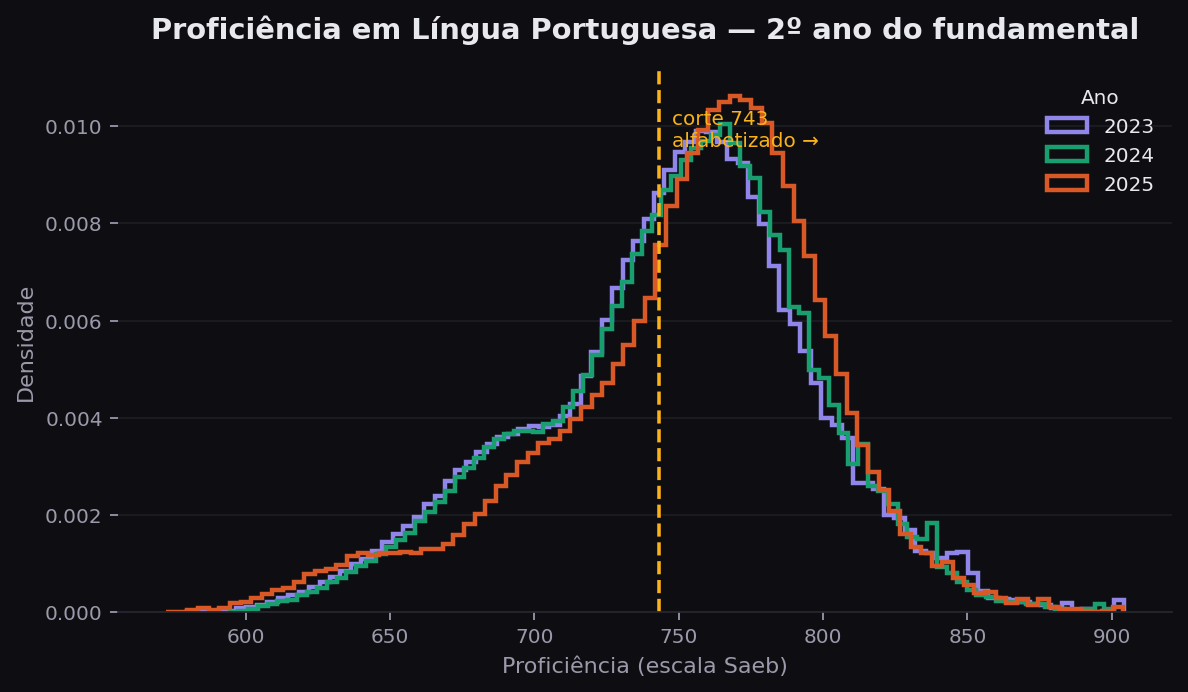

In [5]:
display(Image(filename="../images/01_distribuicao_proficiencia.png"))

## 4. Recorte territorial: a média nacional esconde o problema

O indicador nacional saiu de ~56% (2023) para ~66% (2025). Mas o país não é um bloco só.

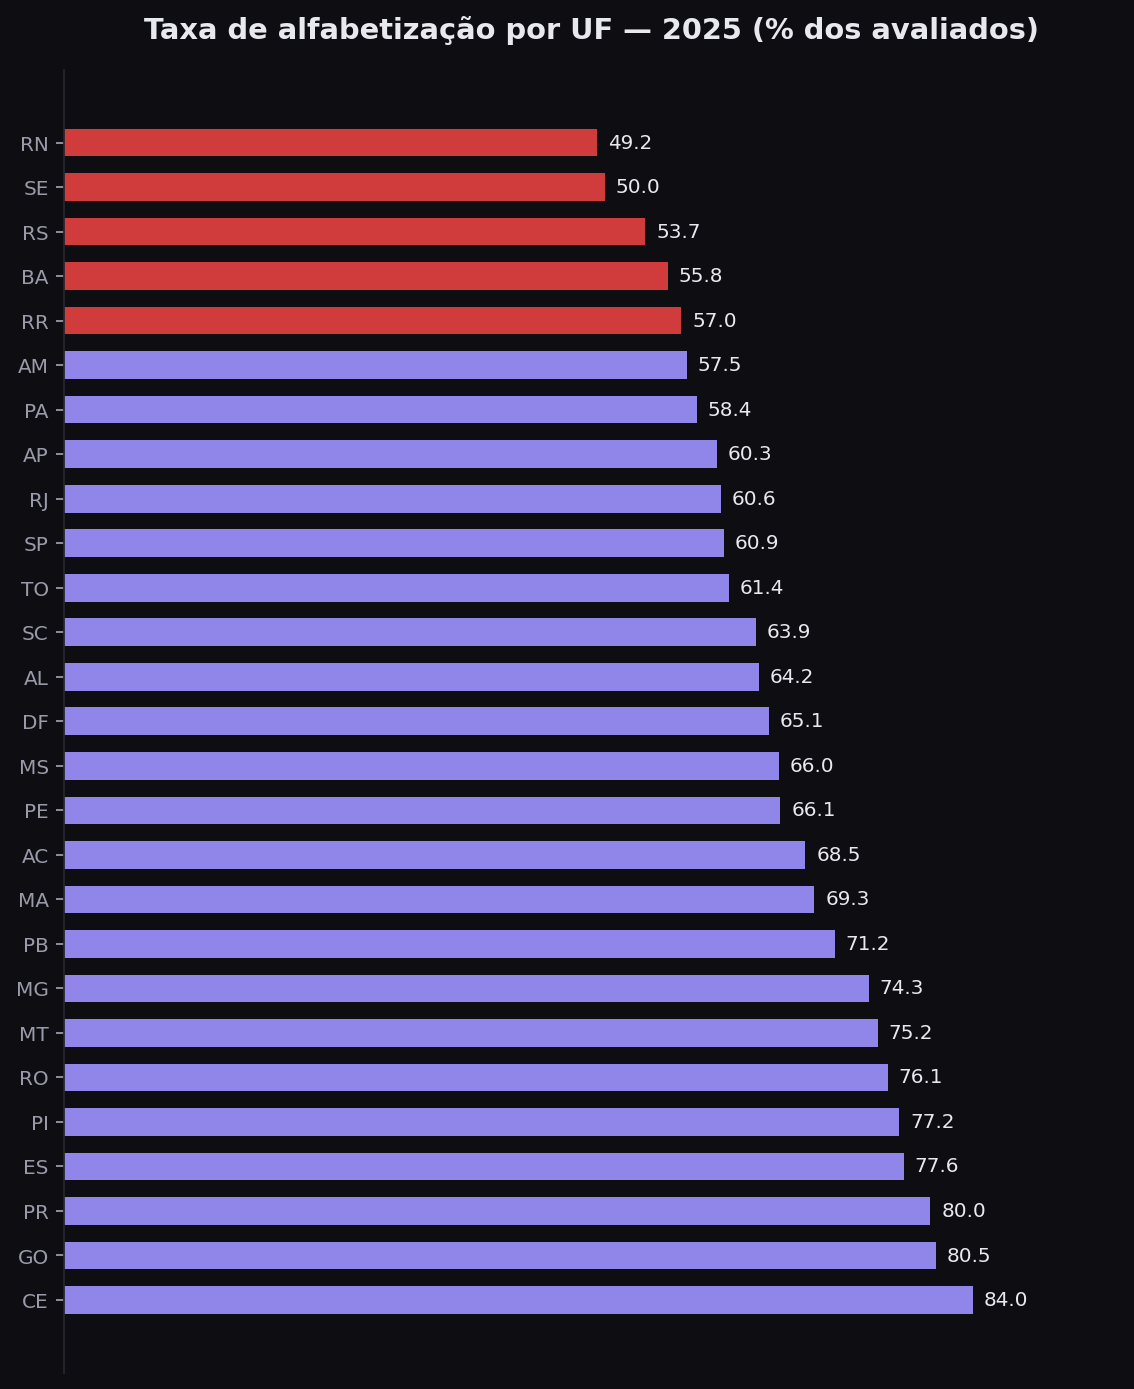

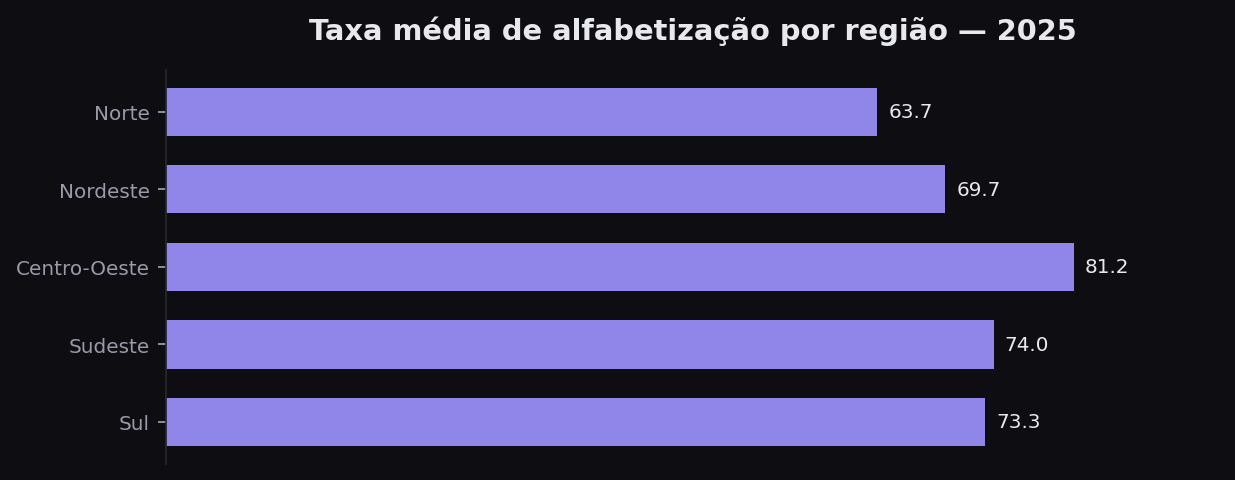

In [6]:
display(Image(filename="../images/02_taxa_por_uf.png"))
display(Image(filename="../images/06_taxa_por_regiao.png"))

In [7]:
stats = json.loads((config.REPORTS_DIR / "eda_estatisticas.json").read_text(encoding="utf-8"))
print("Amplitude entre a melhor e a pior UF: "
      f"{stats['uf_extremos']['amplitude_pp']:.1f} pontos percentuais\n")
print("UFs em situação mais crítica:", stats["uf_extremos"]["piores"])
print("UFs com melhor desempenho: ", stats["uf_extremos"]["melhores"])

Amplitude entre a melhor e a pior UF: 34.8 pontos percentuais

UFs em situação mais crítica: {'RN': 49.2, 'SE': 50.0, 'RS': 53.7, 'BA': 55.8, 'RR': 57.0}
UFs com melhor desempenho:  {'PI': 77.2, 'ES': 77.6, 'PR': 80.0, 'GO': 80.5, 'CE': 84.0}


> **Hipótese 1 — o território importa.** Se a diferença entre a melhor e a pior UF passa de 30
> pontos percentuais, variáveis territoriais devem carregar sinal preditivo relevante.

Vale registrar um resultado contraintuitivo: **não é um gradiente Norte–Sul simples**. O Ceará
lidera com folga e o Rio Grande do Sul aparece entre os piores. Isso é evidência de que **política
educacional local pesa mais que renda regional** — hipótese que o modelo vai testar.

## 5. Persistência: o passado do município prevê o presente?

Esta é a pergunta que sustenta toda a estratégia de features. Se o desempenho de um município é
estável entre anos, o resultado do ano anterior é um preditor legítimo — e disponível *antes* da
avaliação acontecer.

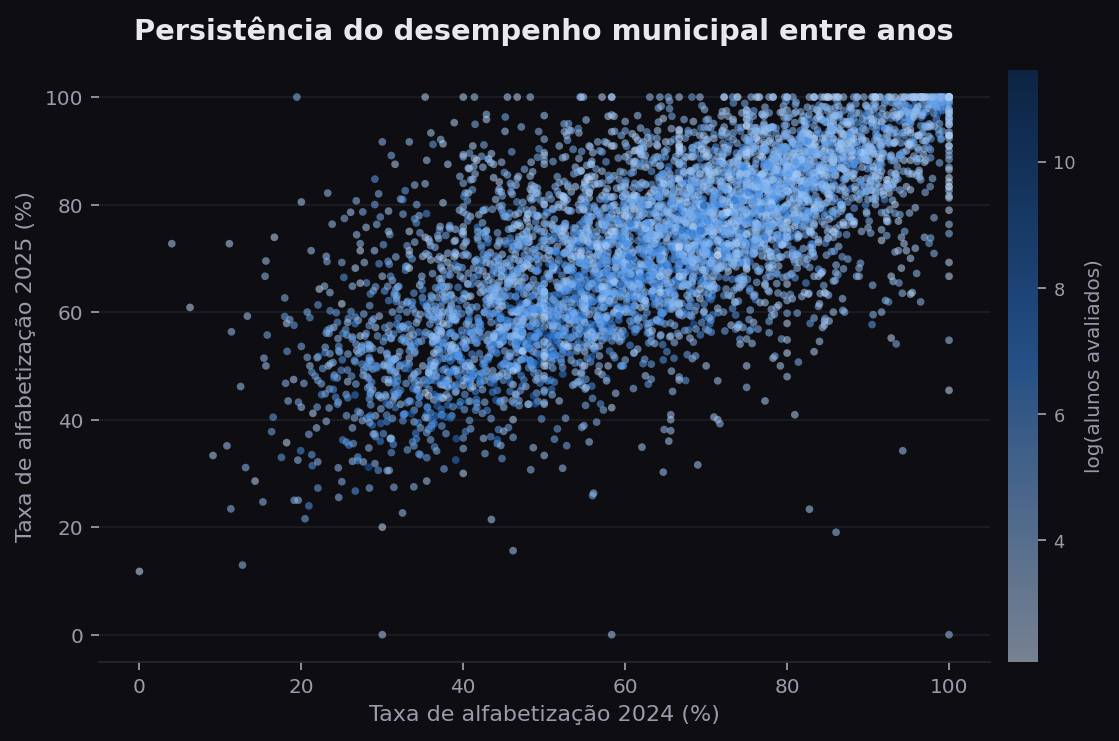

Correlação de Spearman entre a taxa de 2024 e a de 2025: 0.690 (5.509 municípios)


In [8]:
display(Image(filename="../images/04_persistencia_municipal.png"))
print(f"Correlação de Spearman entre a taxa de 2024 e a de 2025: "
      f"{stats['persistencia_municipal']['spearman_2024_2025']:.3f} "
      f"({stats['persistencia_municipal']['municipios']:,} municípios)".replace(",", "."))

> **Hipótese 2 — há forte persistência.** A correlação alta confirma que o histórico municipal
> defasado é a espinha dorsal do conjunto de atributos.

## 6. Armadilha encontrada: o `ID_ESCOLA` não é estável entre edições

A feature mais promissora seria o histórico **por escola** — muito mais granular que o município.
Ao testar, a correlação com o alvo ficou próxima de zero. O motivo: o INEP **reanonimiza o
identificador de escola a cada edição** dos microdados.

In [9]:
mapa24 = alunos[2024].dropna(subset=["id_municipio"]).groupby("id_escola")["id_municipio"].first()
p25 = alunos[2025][(alunos[2025]["presente"] == 1)].dropna(subset=["id_municipio"])
mapa25 = p25.groupby("id_escola")["id_municipio"].first()
juncao = mapa24.to_frame("mun_2024").join(mapa25.to_frame("mun_2025"), how="inner").dropna()

print(f"IDs de escola presentes em 2024 e 2025: {len(juncao):,}".replace(",", "."))
print(f"Mesmo município nos dois anos:          {(juncao['mun_2024'] == juncao['mun_2025']).mean():.2%}")

IDs de escola presentes em 2024 e 2025: 42.391
Mesmo município nos dois anos:          2.01%


**Decisão analítica:** todo histórico por escola foi removido do conjunto de atributos. Cruzar
escola entre anos colaria o passado da escola A no aluno da escola B — ruído puro, com aparência de
sinal. Da escola permanece apenas o que é **estrutural e conhecido antes da prova** (porte da turma
avaliada), que não depende de nenhum resultado.

O contexto defasado passa a ser construído no nível de **município e UF**, cujos códigos IBGE são
estáveis.

## 7. Correlações com o alvo

Correlação de **Spearman** (relação monotônica), mais adequada aqui do que Pearson porque várias
variáveis são assimétricas ou limitadas a intervalos.

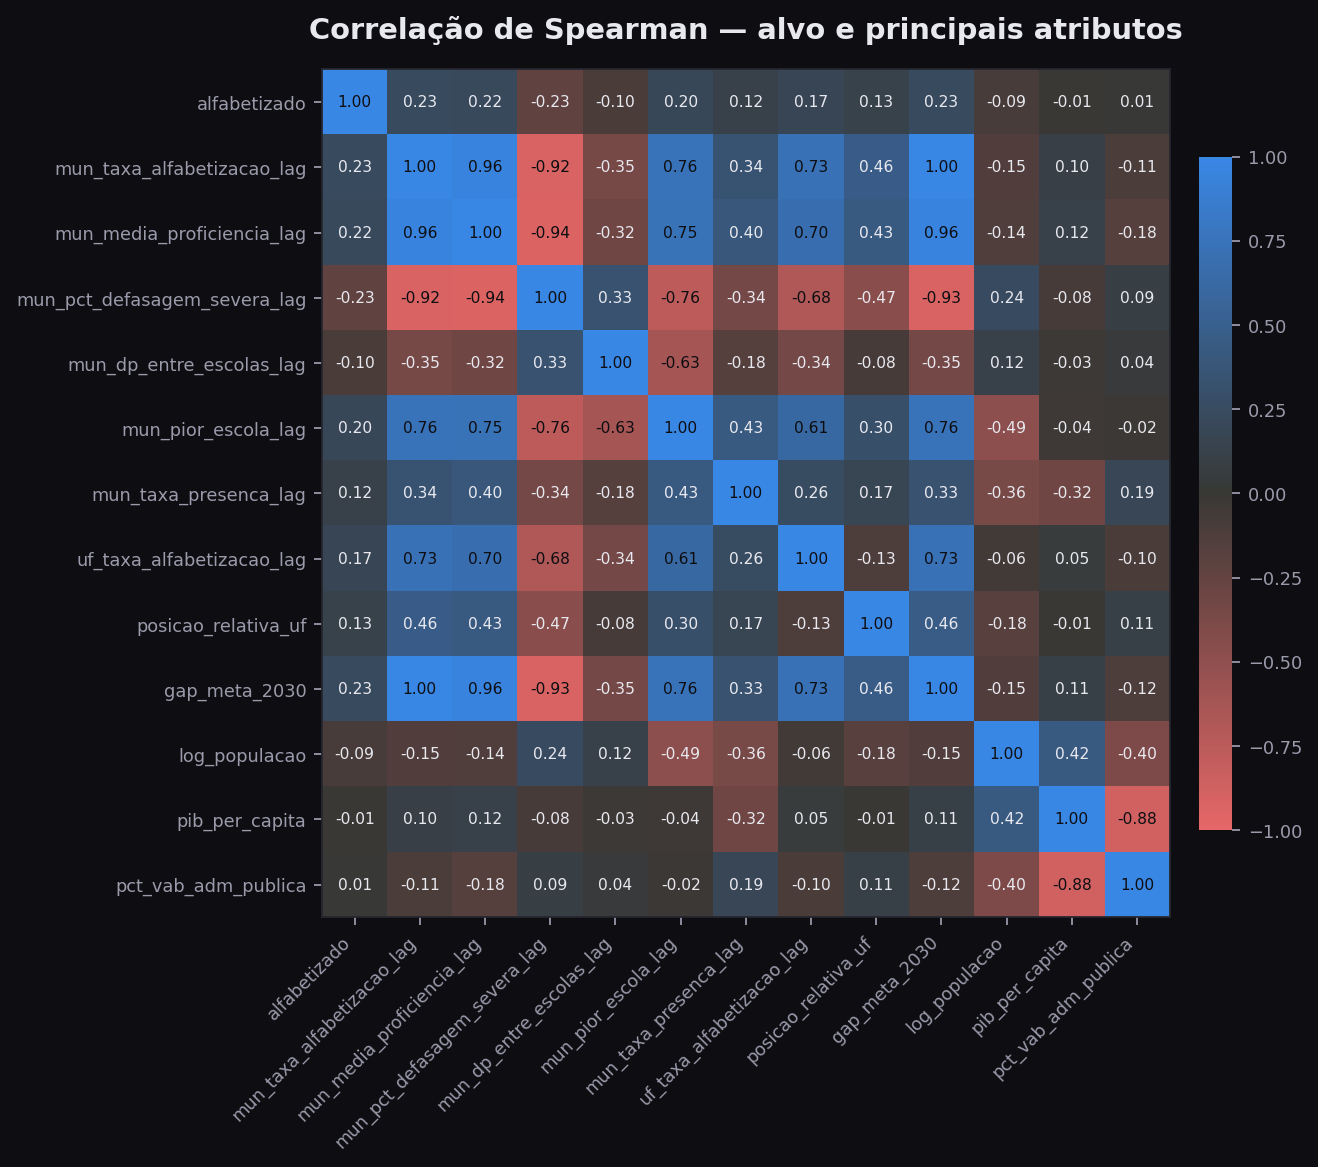

,spearman
mun_taxa_alfabetizacao_lag,0.230
gap_meta_2030,0.229
mun_pct_defasagem_severa_lag,-0.227
mun_media_proficiencia_lag,0.221
mun_pior_escola_lag,0.202
uf_taxa_alfabetizacao_lag,0.173
posicao_relativa_uf,0.128
mun_taxa_presenca_lag,0.121
mun_dp_entre_escolas_lag,-0.096
log_populacao,-0.092


In [10]:
display(Image(filename="../images/03_correlacoes.png"))
pd.Series(stats["correlacao_com_alvo"]).sort_values(key=abs, ascending=False).round(3).to_frame("spearman")

Leitura: o contexto **educacional** do município (taxa do ano anterior, % em defasagem severa,
distância para a meta) domina. As variáveis puramente **socioeconômicas** (PIB per capita,
população) aparecem com correlação bruta baixa.

> **Hipótese 3 — renda não é destino.** O PIB per capita quase não se correlaciona com a taxa de
> alfabetização entre municípios. Se confirmado pelo modelo, é o insight mais relevante para
> política pública deste projeto.

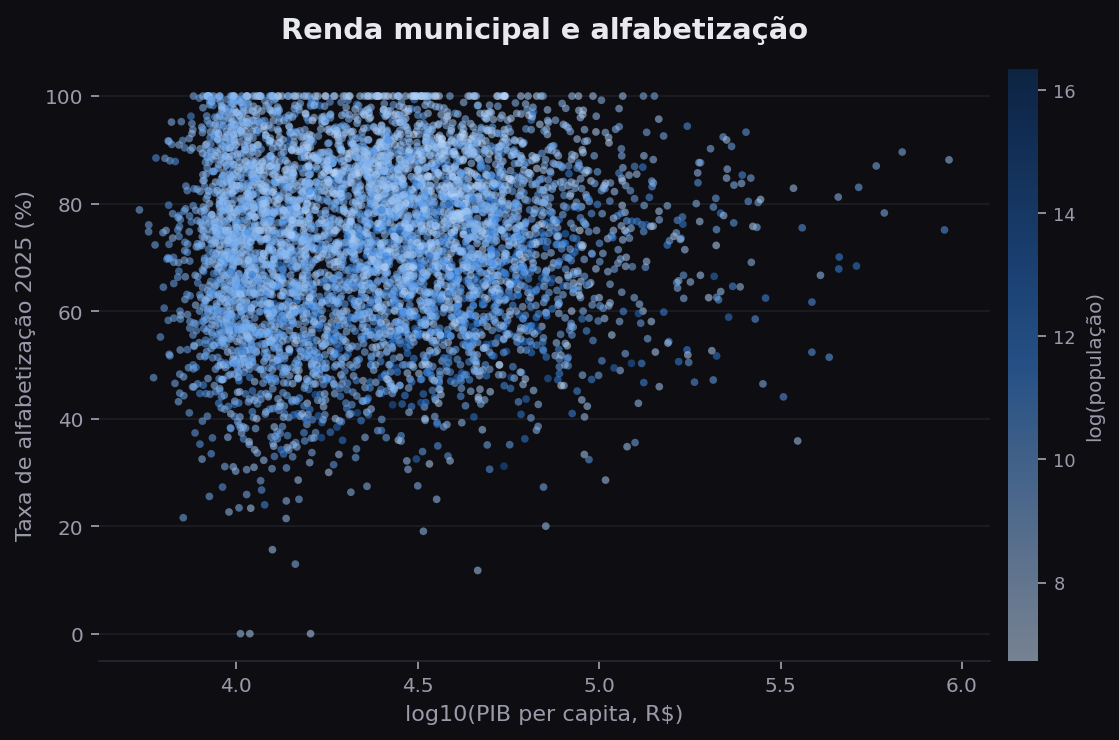

Spearman(PIB per capita, taxa de alfabetização 2025) = 0.044


In [11]:
display(Image(filename="../images/05_pib_x_alfabetizacao.png"))
print(f"Spearman(PIB per capita, taxa de alfabetização 2025) = {stats['correlacao_pib_taxa']:.3f}")

## 8. Desigualdade dentro do município

A média municipal também esconde: escolas do mesmo município variam muito entre si.

In [12]:
print(f"Desvio-padrão médio da taxa entre escolas do mesmo município: "
      f"{stats['heterogeneidade_interna']['dp_media_entre_escolas']:.1f} p.p.")
print(f"Municípios com ao menos uma escola abaixo de 30% de alfabetização: "
      f"{stats['heterogeneidade_interna']['municipios_com_escola_abaixo_de_30pct']:.1f}%")

Desvio-padrão médio da taxa entre escolas do mesmo município: 14.6 p.p.
Municípios com ao menos uma escola abaixo de 30% de alfabetização: 25.6%


> **Hipótese 4 — a dispersão interna é informativa.** Um município com média razoável mas alta
> desigualdade entre escolas esconde bolsões de risco. Por isso incluímos `mun_dp_entre_escolas` e
> `mun_pior_escola` como atributos.

## 9. Distância para as metas

O alvo do segundo modelo. Em 2025, parte relevante dos municípios ficou abaixo da meta do ano.

In [13]:
municipios = pd.read_csv(config.PROCESSED_DIR / "municipio_2025.csv")
print(f"Municípios analisados (rede Municipal): {len(municipios):,}".replace(",", "."))
print(f"Abaixo da meta de 2025:                 {municipios['nao_atingiu_meta'].mean():.1%}")
print(f"Já atingiram o patamar de 2030:         {stats['meta_2030']['ja_atingiram_2030']:.1f}%")
print(f"Gap mediano para a meta de 2030:        {stats['meta_2030']['gap_mediano_para_2030_pp']:.1f} p.p.")

Municípios analisados (rede Municipal): 5.338
Abaixo da meta de 2025:                 27.6%
Já atingiram o patamar de 2030:         35.7%
Gap mediano para a meta de 2030:        6.2 p.p.


## 10. Validação cruzada de fontes

Como a Fase 2 fez entre camadas, comparamos a taxa que **calculamos dos microdados** com a taxa
**publicada** na Base dos Dados. Coerência entre fontes independentes é o que autoriza usar a base
para modelar.

In [14]:
val = pd.read_csv(config.PROCESSED_DIR / "validacao_fontes.csv")
print(f"Municípios comparados: {len(val):,}".replace(",", "."))
print(f"Diferença absoluta média: {val['diferenca_abs'].mean():.3f} p.p.")
print(f"Dentro de 1 p.p.:         {(val['diferenca_abs'] <= 1).mean():.1%}")
print("\nIndicador nacional (rede pública) — microdados x publicado:")
pd.DataFrame(stats["validacao_indicador_nacional"]).T

Municípios comparados: 5.352
Diferença absoluta média: 0.333 p.p.
Dentro de 1 p.p.:         92.9%

Indicador nacional (rede pública) — microdados x publicado:


,calculado_microdados,publicado_base_dos_dados
2023,58.39,55.9
2024,59.78,59.2
2025,66.26,66.0


## Síntese: o que a exploração define para a modelagem

| Achado | Consequência na modelagem |
|---|---|
| Rótulo = proficiência ≥ 743 | `VL_PROFICIENCIA_LP` é vazamento direto e sai da base |
| Ausentes recebem alvo 0 por definição | Universo restrito a alunos presentes |
| `ID_ESCOLA` reanonimizado a cada ano | Histórico por escola removido; contexto vai para município/UF |
| Forte persistência municipal entre anos | Contexto defasado (t−1) vira a espinha dorsal das features |
| Amplitude de 30+ p.p. entre UFs | Variáveis territoriais entram no modelo |
| Alta desigualdade entre escolas do mesmo município | Dispersão e pior escola entram como atributos |
| Renda com correlação baixa | Socioeconômico entra, mas a hipótese é de efeito secundário |
| Distribuição concentrada em torno do corte | Expectativa realista de AUC moderado no grão aluno |

Próximo passo: `02_modelagem_aluno.ipynb`.